<a href="https://colab.research.google.com/github/Javier3883/GCED-AA2/blob/main/es/Examenes_practicas/Practica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1

En este ejercicio se va a crear un sistema de aprendizaje supervisado sobre el dataset [ISOLET](https://archive.ics.uci.edu/dataset/54/isolet). Ten en cuenta que este es un problema de clasificación multiclase. Las etiquetas son números enteros que indican la clase. Tu modelo debe predecir un vector que represente una distribución de probabilidad a lo largo de las distintas clases. La función de pérdida que debes utilizar es [nn.CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). Fíjate en que esta función espera que la salida de tu red no esté normalizada con una función softmax (lee la documentación y haz pruebas para aprender a utilizarla correctamente).

## Carga del dataset

Esta celda se encargará de bajar el dataset a vuestro ordenador. Tened en cuenta que puede haber fallos, ya que el repositorio de UCI desde donde se descarga tiene muchas peticiones simultáneas.

In [1]:
import os
import numpy as np
from scipy.io import loadmat
import torch
import random
from sklearn.model_selection import KFold

# Fijamos la semilla para poder reproducir los resultados
seed = 1234
os.environ['PYTHONHASHSEED'] = str(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

def download_dataset(directory):
    if not os.path.isdir(directory):
        os.makedirs(directory)

    filename = 'Isolet.mat'
    url = 'https://jundongl.github.io/scikit-feature/files/datasets/Isolet.mat'
    filepath = os.path.join(directory, filename)

    if not os.path.isfile(filepath):
        torch.hub.download_url_to_file(url, filepath)


def load_dataset(directory=None):
    directory = directory or './isolet/'
    download_dataset(directory=directory)
    dataset = load_data(directory + 'Isolet.mat')
    return dataset


def load_data(source):
    dataset = loadmat(source)
    return dataset['X'].astype(np.float32), dataset['Y'].astype(int)


In [2]:
from sklearn.model_selection import train_test_split
import torch.utils.data as data

# Cargamos el dataset
X, y = load_dataset()
y = y - 1 # para que las clases emppiecen en 0
n_classes = np.unique(y).size

# Usa estas particiones exactamente
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed) # divide 20% test, 80% entrenamiento

## Preprocesado

Preprocesa los datos como necesites, con el objetivo de facilitar el entrenamiento de la red. Recuerda que, si vas a utilizar valores estadísticos de los datos, éstos sólo pueden ser obtenidos de los datos de la partición de train. Es decir, **no se puede aplicar la función fit (o fit_transform) sobre los datos de validación o test**.

In [3]:
# TODO - Haz el preprocesado que necesites
from sklearn.preprocessing import StandardScaler

# Ajuste y transformación solo en el conjunto de entrenamiento
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Transformación test usando el escalador ajustado con train
X_test = scaler.transform(X_test) # no se ajusta, para que no se pierda información del conjunto de test

# Conversión a tensores PyTorch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# CrossEntropyLoss requiere etiquetas enteras (LongTensor)
y_train = torch.tensor(y_train.squeeze(), dtype=torch.long)
y_test = torch.tensor(y_test.squeeze(), dtype=torch.long)

## Trabajo a realizar

```
 NOTA: Para todos los entrenamientos se utilizarán los siguientes parámetros:
 - Adam como optimizador
 - Tasa de aprendizaje de 0.001
 - Tamaño de batch de 100
 - Duración de 100 iteraciones (epochs).
```

### 1. Entrenamiento simple
Entrena un modelo de red neuronal totalmente conectada. El número de capas ocultas será de 2, con 50 neuronas por capa, una regularización l2 de 0.01, y ReLU como función de activación para las capas ocultas. Utiliza [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) para el particionamiento, probando con distintos valores de k (3, 5 y 10).

Debes ser capaz de responder a las siguientes preguntas:
1. ¿Cuál es la precisión del modelo?
1. ¿Qué conclusiones sacas respecto a la variación de los resultados al cambiar k?

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
import numpy as np

# Configuración de hiperparámetros
batch_size = 100
epochs = 100
l2_reg = 0.01
k_values = [3, 5, 10]
input_dim = X_train.shape[1]

loss_fn = nn.CrossEntropyLoss()

print("=== APARTADO 1: ENTRENAMIENTO SIMPLE ===")

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    val_accuracies = []

    for train_idx, val_idx in kf.split(X_train):
        # 1. Separación de folds
        X_tr, y_tr = X_train[train_idx], y_train[train_idx]
        X_va, y_va = X_train[val_idx], y_train[val_idx]

        # 2. Dataloader para el batch size indicado
        train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

        # 3. Definición de la red (2 capas ocultas con 50 neuronas y ReLU)
        model = nn.Sequential(
                              nn.Linear(input_dim, 50), # 1º capa oculta
                              nn.ReLU(), # f.activacion capa 1
                              nn.Linear(50, 50), # capa intermedia
                              nn.ReLU(),# f.activacion capa 2
                              nn.Linear(50, n_classes) # 2 capa oculta
                          )

        # 4. Optimizador Adam con regularización L2 (weight_decay)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=l2_reg)

        # 5. Bucle de entrenamiento
        for epoch in range(epochs):
            model.train()
            for bx, by in train_loader:
                optimizer.zero_grad()
                outputs = model(bx)
                loss = loss_fn(outputs, by)
                loss.backward()
                optimizer.step()

        # 6. Evaluación en el conjunto de validación del fold
        model.eval()
        with torch.no_grad():
            outputs_val = model(X_va)
            preds_val = torch.argmax(outputs_val, dim=1)
            acc = (preds_val == y_va).float().mean().item()
            val_accuracies.append(acc)

    mean_acc = np.mean(val_accuracies)
    std_acc = np.std(val_accuracies)
    print(f"k = {k:2d} | Precisión (Accuracy) media en validación: {mean_acc:.4f} ± {std_acc:.4f}")

=== APARTADO 1: ENTRENAMIENTO SIMPLE ===
k =  3 | Precisión (Accuracy) media en validación: 0.9391 ± 0.0011
k =  5 | Precisión (Accuracy) media en validación: 0.9495 ± 0.0135
k = 10 | Precisión (Accuracy) media en validación: 0.9447 ± 0.0136


        1. ¿Cuál es la precisión del modelo?
        La precisión varía con la K. Con k = 3  ==> accuracy : 0.9391
                                         k = 5  ==> accuracy : 0.9487
                                         k = 10 ==> accuracy : 0.9455
        2. ¿Qué conclusiones sacas de los resultados del punto anterior?
        Con k = 3, uso 2 de cada 3 datos para entrenar (66% de los datos). Como resultado una menor precisión
        Con k = 5, uso 4 de cada 5 datos para entrenar (80% datos). Mayor precisión
        Con k = 10, uso 9 de cada 10 datos para entrenar (90% datos entrenamiento y 10 % validación), cada error individual penaliza mucho más que con k = 5  

        La pequeña caída del rendimiento en k=10 no significa que el modelo sea peor entrenando con más datos, sino que la precisión se vuelve más sensible a pequeñas variaciones debido a la reducción a la mitad del tamaño de los conjuntos de validación en cada fold

### 2. Búsqueda de mejores hiperparámetros
Para un k-fold con k=3, queremos buscar un modelo que se adecúe de la mejor manera posible al problema. Para ello, probaremos distintas configuraciones. En concreto, se entrenarán modelos con todas las variaciones posibles de los parámetros siguientes:
1. 1, 5 o 10 capas ocultas
1. 10, 50 o 100 número de neuronas de las capas ocultas (todas las capas usarán el mismo valor)
1. 4 valores distintos de regularización por norma l2 (0.0001, 0.001, 0.01 o 0.1).
1. 2 funciones de activación distintas para la capa oculta (ReLU o Tanh).

Asegúrate de que:
 - Se han realizado todas las permutaciones posibles
 - No hay repeticiones innecesarias de código
 - No se ha utilizado el conjunto de validación para entrenar el modelo (ni como criterio de parada)
 - Al final de los entrenamientos, se muestra la precisión (accuracy) del mejor y del peor modelo, así como los parámetros que se han utilizado para crear dichos modelos. También se mostrará la precisión del modelo obtenida con los datos usados en entrenamiento.
 - Para los mejores y peores modelos, investiga si están sobreentrenando o si les falta capacidad.
 - Identificas qué hiperparámetros afectan más y cuáles menos al entrenamiento.

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold

activations = ['relu', 'tanh']
regularizations = [1e-4, 1e-3, 1e-2, 1e-1]
hidden_layer_elements_list = [10, 50, 100]
n_hidden_layers_list = [1, 5, 10]

# Registra los resultados en estos diccionarios respetando el formato dado
resultados_train = {}
resultados_validacion = {}

for i in activations:
    resultados_train[i] = {}
    resultados_validacion[i] = {}
    for j in regularizations:
        resultados_train[i][j] = {}
        resultados_validacion[i][j] = {}
        for k in hidden_layer_elements_list:
            resultados_train[i][j][k] = {}
            resultados_validacion[i][j][k] = {}

# TODO - Búsqueda de hiperparámetros

kf = KFold(n_splits=3, shuffle=True, random_state=seed)
loss_fn = nn.CrossEntropyLoss()

# 1. Bucles iterativos para recorrer todas las combinaciones
for act in activations:
    for reg in regularizations:
        for hid_n in hidden_layer_elements_list:
            for n_hid in n_hidden_layers_list:

                fold_accs_tr = []
                fold_accs_va = []

                # 2. Bucle iterativo para KFold (k=3)
                for train_idx, val_idx in kf.split(X_train):
                    X_tr, y_tr = X_train[train_idx], y_train[train_idx]
                    X_va, y_va = X_train[val_idx], y_train[val_idx]

                    # Definición de la red en el mismo sitio
                    fn_act = nn.ReLU if act == 'relu' else nn.Tanh
                    capas = [nn.Linear(X_train.shape[1], hid_n), fn_act()]
                    for _ in range(n_hid - 1):
                        capas.extend([nn.Linear(hid_n, hid_n), fn_act()])
                    capas.append(nn.Linear(hid_n, n_classes))

                    model = nn.Sequential(*capas)
                    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=reg)
                    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=100, shuffle=True)

                    # Entrenamiento (100 épocas)
                    for _ in range(100):
                        model.train()
                        for bx, by in loader:
                            optimizer.zero_grad()
                            loss_fn(model(bx), by).backward()
                            optimizer.step()

                    # Evaluación (sin usar validación para ajustar el modelo)
                    model.eval()
                    with torch.no_grad():
                        acc_tr = (torch.argmax(model(X_tr), dim=1) == y_tr).float().mean().item()
                        acc_va = (torch.argmax(model(X_va), dim=1) == y_va).float().mean().item()

                        fold_accs_tr.append(acc_tr)
                        fold_accs_va.append(acc_va)

                # Almacenar la media de los 3 folds directamente en las posiciones del diccionario
                resultados_train[act][reg][hid_n][n_hid] = float(np.mean(fold_accs_tr))
                resultados_validacion[act][reg][hid_n][n_hid] = float(np.mean(fold_accs_va))

# 3. Búsqueda iterativa simple del mejor y peor resultado
best_acc = -1.0
worst_acc = 2.0
best_params = None
worst_params = None

for act in activations:
    for reg in regularizations:
        for hid_n in hidden_layer_elements_list:
            for n_hid in n_hidden_layers_list:
                acc_v = resultados_validacion[act][reg][hid_n][n_hid]

                if acc_v > best_acc:
                    best_acc = acc_v
                    best_params = (act, reg, hid_n, n_hid)

                if acc_v < worst_acc:
                    worst_acc = acc_v
                    worst_params = (act, reg, hid_n, n_hid)

# Extracción de valores
b_act, b_reg, b_hid_n, b_n_hid = best_params
w_act, w_reg, w_hid_n, w_n_hid = worst_params

print("=== MEJOR MODELO ===")
print(f"Parámetros: Activación={b_act}, Regularización={b_reg}, Neuronas={b_hid_n}, Capas={b_n_hid}")
print(f"Accuracy Train: {resultados_train[b_act][b_reg][b_hid_n][b_n_hid]*100:.2f}%")
print(f"Accuracy Validación: {resultados_validacion[b_act][b_reg][b_hid_n][b_n_hid]*100:.2f}%\n")

print("=== PEOR MODELO ===")
print(f"Parámetros: Activación={w_act}, Regularización={w_reg}, Neuronas={w_hid_n}, Capas={w_n_hid}")
print(f"Accuracy Train: {resultados_train[w_act][w_reg][w_hid_n][w_n_hid]*100:.2f}%")
print(f"Accuracy Validación: {resultados_validacion[w_act][w_reg][w_hid_n][w_n_hid]*100:.2f}%")

=== MEJOR MODELO ===
Parámetros: Activación=tanh, Regularización=0.0001, Neuronas=100, Capas=1
Accuracy Train: 100.00%
Accuracy Validación: 95.27%

=== PEOR MODELO ===
Parámetros: Activación=relu, Regularización=0.01, Neuronas=10, Capas=10
Accuracy Train: 4.57%
Accuracy Validación: 2.72%


### 3. Visualiza los resultados

Usa el código de la siguiente celda para visualizar la precisión mediante el uso de mapas de calor. Usa las siguientes combinaciones:
1. Número de capas ocultas vs Número de neuronas por capa
1. Número de capas ocultas vs Regularización
1. Número de neuronas por capa vs Regularización

```Vigila el no repetir código innecesariamente. No se deben re-entrenar los modelos, ya que las estadísticas deben haber sido guardadas en el formato apropiado en el punto anterior.```


Analiza los resultados. ¿Qué problemáticas entiendes que se están produciendo?

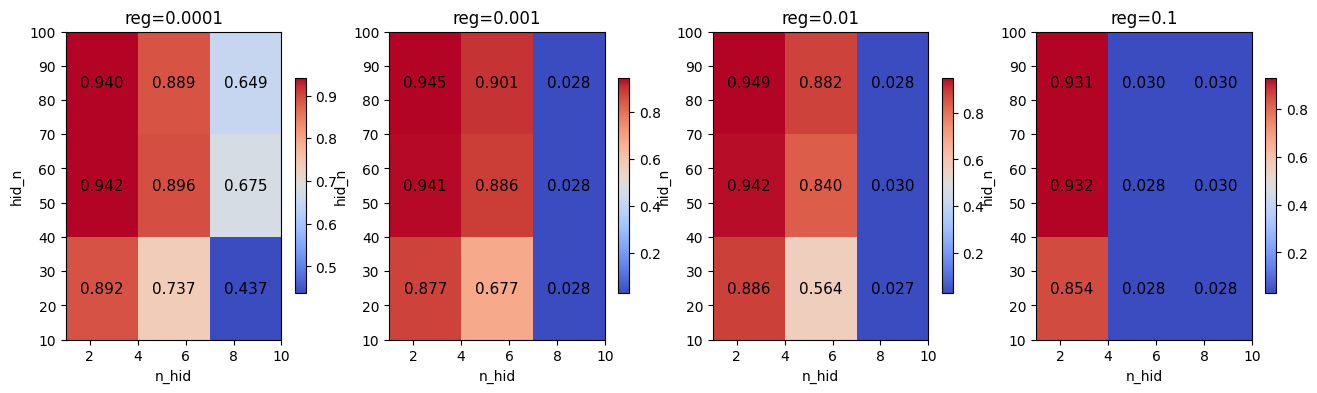

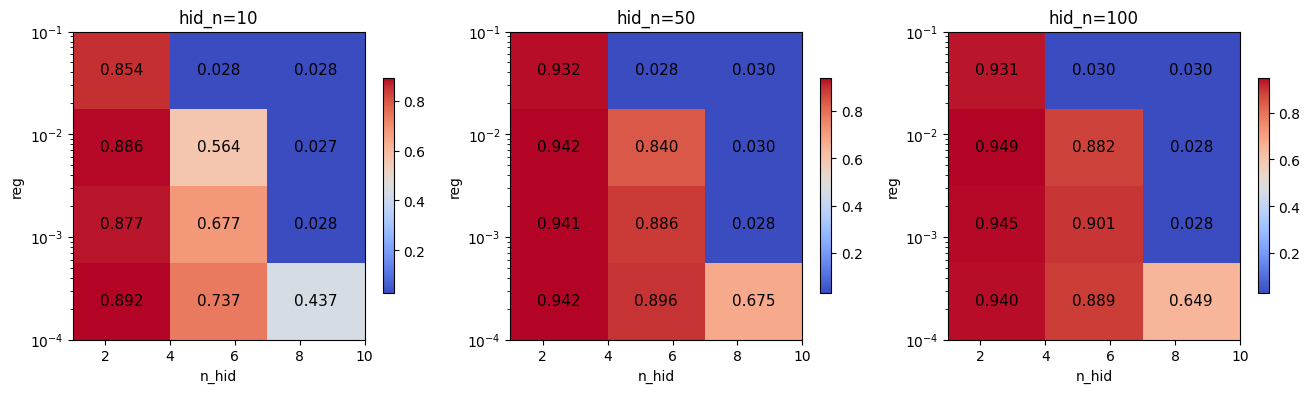

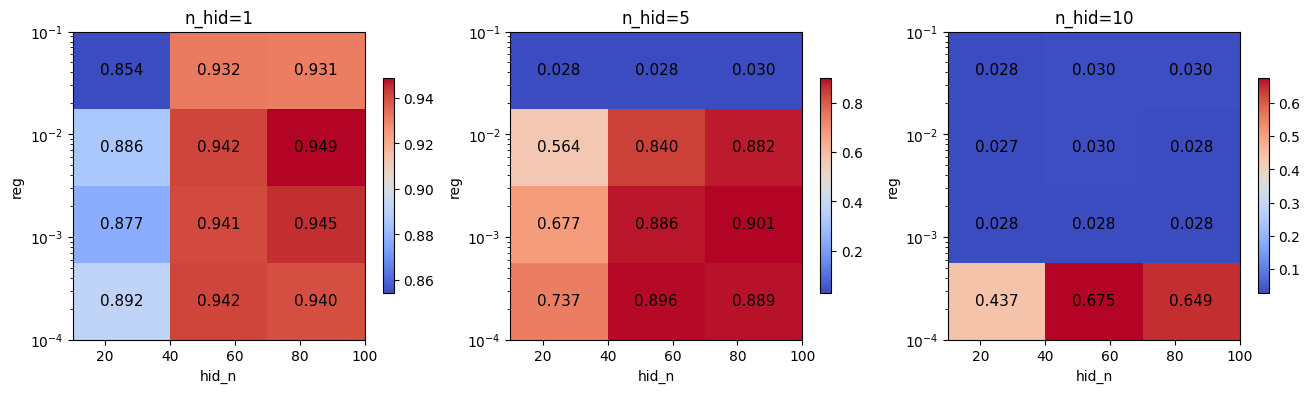

In [6]:
# Se facilita el código de generación del mapa de calor a partir de los resultados registrados

import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

def plot_heatmap_with_values(results, grids, xaxis, yaxis, naxis, activation, fmt="{:.3f}", log_y=False):
    X = np.array(grids[xaxis])
    Y = np.array(grids[yaxis])


    fig, ax_t = plt.subplots(1,len(grids[naxis]), figsize=(16,4))
    for n, nv in enumerate(grids[naxis]):
        ax = ax_t[n]
        # Build Z grid
        Z = []
        comb = {}
        comb['act'] = activation
        comb[naxis] = nv
        for yval in grids[yaxis]:
            comb[yaxis] = yval
            Z_row = []
            for xval in grids[xaxis]:
                comb[xaxis] = xval
                Z_row.append(results[comb['act']][comb['reg']][comb['hid_n']][comb['n_hid']])
            Z.append(Z_row)
        Z = np.array(Z)

        # Compute cell centers along X and Y
        x_edges = np.linspace(X.min(), X.max(), Z.shape[1]+1)
        y_edges = np.linspace(Y.min(), Y.max(), Z.shape[0]+1)
        x_centers = (x_edges[:-1] + x_edges[1:]) / 2
        y_centers = (y_edges[:-1] + y_edges[1:]) / 2

        if log_y:
            ax.set_yscale('log')
            # Compute edges in log space
            y_edges = np.logspace(np.log10(Y.min()), np.log10(Y.max()), Z.shape[0]+1)
            # Compute centers in log space
            y_centers = (y_edges[:-1] * y_edges[1:])**0.5   # geometric mean

        pc = ax.pcolormesh(x_edges, y_edges, Z, cmap=cm.coolwarm, shading='auto')

        # Add numeric labels at cell centers
        for i in range(Z.shape[0]):
            for j in range(Z.shape[1]):
                ax.text(x_centers[j], y_centers[i], fmt.format(Z[i, j]),
                        ha="center", va="center", color="black", fontsize=11)

        ax.set_xlabel(xaxis)
        ax.set_ylabel(yaxis)
        ax.set_title(f'{naxis}={nv}')
        fig.colorbar(pc, ax=ax, shrink=0.7)

    plt.show()

grids = {'act':activations, 'reg':regularizations, 'hid_n':hidden_layer_elements_list, 'n_hid':n_hidden_layers_list}

# Llamadas de ejemplo
# TODO - Sustituir por las llamadas correctas
# 1. Número de capas ocultas ('n_hid') vs Número de neuronas por capa ('hid_n')
plot_heatmap_with_values(resultados_validacion, grids, xaxis='n_hid', yaxis='hid_n', naxis='reg', activation='relu')

# 2. Número de capas ocultas ('n_hid') vs Regularización ('reg')
plot_heatmap_with_values(resultados_validacion, grids, xaxis='n_hid', yaxis='reg', naxis='hid_n', activation='relu', log_y=True)

# 3. Número de neuronas por capa ('hid_n') vs Regularización ('reg')
plot_heatmap_with_values(resultados_validacion, grids, xaxis='hid_n', yaxis='reg', naxis='n_hid', activation='relu', log_y=True)